<a href="https://colab.research.google.com/github/Dongjin-1203/codeit_mission/blob/main/%EB%AF%B8%EC%85%9811_1%ED%8C%80_%EC%A7%80%EB%8F%99%EC%A7%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 미션 소개
이번 미션은 기계 번역 실습으로, 한국어 문장을 영어로 번역하는 모델을 구축하는 프로젝트입니다. 총 3가지 모델(Seq2Seq 기본 모델, Attention 적용 모델)을 구현하고 학습시키며, 각 모델의 성능을 비교 분석해 보세요.

## 사용 데이터셋
미션 11 데이터셋(구어체 한영 병렬 말뭉치)

## 데이터 형식

미션에 사용되는 데이터셋은 JSON 파일 형식으로 제공되며, 각 항목은 한국어 문장("ko")과 영어 번역문("mt")으로 구성되어 있습니다.
파일 경로 예시

- 훈련 데이터: `.../일상생활및구어체_한영_train_set.json`
- 검증 데이터: `.../일상생활및구어체_한영_valid_set.json`
- (파일 경로는 여러분의 환경에 맞게 수정해 주세요.)

## 가이드라인

### 데이터 전처리
적절한 토크나이저를 선택하여 한국어, 영어 문장을 토큰화하세요.
문장 길이를 분석하여, 전체 문장의 길이에 맞게 최대 길이(MAX_LENGTH)를 설정하고, 필요한 경우 SOS, EOS, PAD, UNK 등의 특수 토큰을 정의합니다.

### 어휘 사전 구축
한국어와 영어 각각의 어휘 사전을 구성하세요.
단어의 등장 빈도를 고려하여, 추후 임베딩이나 기타 모델 구성에 활용할 수 있습니다.

### 텐서 변환 및 데이터 로더 구현
각 문장을 토큰의 인덱스 시퀀스로 변환한 후, 고정 길이에 맞게 PAD 토큰으로 패딩합니다.
TensorDataset과 DataLoader를 활용하여 학습 데이터를 배치 단위로 효율적으로 처리할 수 있도록 구현하세요.

### 모델 구현 및 학습
#### Seq2Seq 모델
기본 GRU 기반의 Encoder-Decoder 모델을 구현하고, Teacher Forcing 기법을 적용해 학습합니다.
#### Attention 모델
Bahdanau Attention(Bahdanau 혹은 Luong)을 적용한 디코더를 구현하여, 번역 성능을 높여 보세요.

###모델 학습 및 평가
각 모델별로 학습을 진행한 후, 평가 함수를 활용하여 번역 결과를 확인합니다.
무작위 문장 쌍에 대해 모델의 번역 결과를 출력하고, 출력 문장을 정제(특수 토큰 제거 등)하여 성능을 분석해 보세요.

## 추가 실험 (선택)
- 데이터 전처리 방법 개선(예: 불용어 제거, 정규화 등)
- 모델 구조 변경(레이어 수, 은닉 상태 크기, Attention 기법 수정 등)
- 하이퍼파라미터 튜닝(학습률, 배치 크기 등)
- 다양한 평가 지표(예: BLEU 점수) 도입

## 제출 안내
다음 내용을 포함한 **Colab Notebook** 파일을 제출해 주세요.

파일 이름은 `11_{팀명}_{성함}.ipynb` 형태로 해 주세요.

1. 모델 구현 및 학습 결과
    - 기계 번역 모델(Seq2Seq, Seq2Seq with Attention)을 구현하고, 데이터 로드 → 전처리 → 임베딩 적용 → 모델 구축 및 학습 → 예측 및 평가 과정을 순차적으로 진행하세요.

2. 마크다운을 활용한 설명
    - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
    - 노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해 주세요.

3. 모델 성능 평가 및 제출
    - 생성된 텍스트의 품질을 정성적(번역 결과 확인) 및 정량적(BLUE 등, optional)으로 평가해 보세요.
    - 테스트 데이터셋에 대한 번역 결과를 포함해 주세요.

## 학습 과정

### 초기 세팅

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,892 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and dire

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 기존 폴더로 이동
import os
os.chdir('/content/drive/MyDrive/codeit/딥러닝/NLP')

In [3]:
!pwd

/content/drive/MyDrive/codeit/딥러닝/NLP


In [4]:
# 데이터 압축 관련
import zipfile
import os
from pathlib import Path

# 데이터 EDA 관련
import json
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
import seaborn as sns

In [31]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

### 데이터 압축 해제(최초만 실행)

In [9]:
def extract_zip_with_structure(zip_file_path, extract_to_path=None, verbose=True):
    """
    압축파일을 디렉토리 구조를 유지하며 압축해제하는 함수
    """

    # 압축파일 존재 여부 확인
    if not os.path.exists(zip_file_path):
        raise FileNotFoundError(f"압축파일을 찾을 수 없습니다: {zip_file_path}")

    # 압축해제 경로 설정
    if extract_to_path is None:
        extract_to_path = os.getcwd()

    # 압축해제 대상 폴더 생성
    Path(extract_to_path).mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            # 압축파일 내용 확인
            file_list = zip_ref.namelist()

            if verbose:
                print(f"압축파일: {zip_file_path}")
                print(f"압축해제 경로: {extract_to_path}")
                print(f"총 파일/폴더 개수: {len(file_list)}개")
                print("=" * 50)

                # 최상위 폴더들 확인
                top_level_dirs = set()
                for item in file_list:
                    if '/' in item:
                        top_level_dirs.add(item.split('/')[0])
                    else:
                        if not item.endswith('.'):  # 파일인 경우
                            top_level_dirs.add(item)

                print(f"최상위 폴더들: {sorted(top_level_dirs)}")
                print("=" * 50)

            # 각 항목을 개별적으로 처리
            extracted_count = 0
            failed_items = []

            for item in file_list:
                try:
                    # 대상 경로 생성
                    target_path = os.path.join(extract_to_path, item)

                    # 디렉토리인 경우 (경로가 /로 끝나는 경우)
                    if item.endswith('/'):
                        Path(target_path).mkdir(parents=True, exist_ok=True)
                        if verbose and extracted_count < 10:  # 처음 10개만 출력
                            print(f"디렉토리 생성: {item}")
                    else:
                        # 파일인 경우
                        # 먼저 상위 디렉토리 생성
                        parent_dir = os.path.dirname(target_path)
                        if parent_dir:
                            Path(parent_dir).mkdir(parents=True, exist_ok=True)

                        # 파일 추출
                        with zip_ref.open(item) as source_file:
                            with open(target_path, 'wb') as target_file:
                                target_file.write(source_file.read())

                        if verbose and extracted_count < 10:  # 처음 10개만 출력
                            print(f"파일 추출: {item}")

                    extracted_count += 1

                except Exception as e:
                    failed_items.append((item, str(e)))
                    if verbose:
                        print(f"실패: {item} - {str(e)}")

            if verbose:
                print("=" * 50)
                print(f"압축해제 완료! 성공: {extracted_count}개, 실패: {len(failed_items)}개")

                if failed_items:
                    print("\n실패한 항목들:")
                    for item, error in failed_items:
                        print(f"  - {item}: {error}")

                # 압축해제된 폴더 구조 확인
                print("\n압축해제된 폴더 구조 확인:")
                check_extracted_structure(extract_to_path)

            return extract_to_path

    except zipfile.BadZipFile:
        raise ValueError(f"올바르지 않은 압축파일입니다: {zip_file_path}")
    except Exception as e:
        raise Exception(f"압축해제 중 오류가 발생했습니다: {str(e)}")

In [10]:
def check_extracted_structure(base_path, max_depth=3):
    """
    압축해제된 폴더 구조를 확인하는 함수
    """
    for root, dirs, files in os.walk(base_path):
        level = root.replace(base_path, '').count(os.sep)
        if level >= max_depth:
            continue

        indent = '  ' * level
        folder_name = os.path.basename(root) if os.path.basename(root) else 'Root'

        # 폴더 정보 출력
        file_count = len(files)
        dir_count = len(dirs)
        print(f"{indent}📁 {folder_name}/ (폴더: {dir_count}개, 파일: {file_count}개)")

        # 파일들 중 일부만 표시
        if files:
            subindent = '  ' * (level + 1)
            show_files = files[:3]  # 처음 3개만 표시
            for file in show_files:
                file_size = os.path.getsize(os.path.join(root, file))
                print(f"{subindent}📄 {file} ({file_size:,} bytes)")

            if len(files) > 3:
                print(f"{subindent}... 외 {len(files) - 3}개 파일")

In [11]:
def verify_specific_folders(base_path, expected_folders=['test_images', 'train_annotations', 'train_images']):
    """
    특정 폴더들이 제대로 생성되었는지 확인하는 함수
    """
    print("\n🔍 주요 폴더 존재 확인:")
    for folder in expected_folders:
        folder_path = os.path.join(base_path, folder)
        if os.path.exists(folder_path):
            if os.path.isdir(folder_path):
                file_count = sum(len(files) for _, _, files in os.walk(folder_path))
                print(f"✅ {folder}/ - 존재함 ({file_count}개 파일)")
            else:
                print(f"❌ {folder} - 파일로 존재함 (폴더가 아님)")
        else:
            print(f"❌ {folder}/ - 존재하지 않음")


In [17]:
if __name__ == "__main__":
    extract_path = extract_zip_with_structure("./data/일상생활및구어체한영.zip", "./data")


압축파일: ./data/일상생활및구어체한영.zip
압축해제 경로: ./data
총 파일/폴더 개수: 2개
최상위 폴더들: ['일상생활및구어체_한영_train_set.json', '일상생활및구어체_한영_valid_set.json']
파일 추출: 일상생활및구어체_한영_train_set.json
파일 추출: 일상생활및구어체_한영_valid_set.json
압축해제 완료! 성공: 2개, 실패: 0개

압축해제된 폴더 구조 확인:
📁 data/ (폴더: 0개, 파일: 3개)
  📄 일상생활및구어체한영.zip (142,925,371 bytes)
  📄 일상생활및구어체_한영_train_set.json (972,643,210 bytes)
  📄 일상생활및구어체_한영_valid_set.json (121,536,888 bytes)


### 데이터 EDA

#### 파일 구조, 샘플 확인

In [6]:
# JSON 파일 불러오기
def load_json(file_path, max_samples=1000):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data["data"][:max_samples]

In [7]:
# JSON 파일 읽기 (각 라인이 JSON 객체)
train_json = "./data/일상생활및구어체_한영_train_set.json"
valid_json = "./data/일상생활및구어체_한영_valid_set.json"

data_train = load_json(train_json, max_samples=50000)
data_valid = load_json(valid_json, max_samples=1000)

In [8]:
data_train

[{'sn': 'INTSALDSUT062119042703238',
  'data_set': '일상생활및구어체',
  'domain': '해외영업',
  'subdomain': '도소매유통',
  'ko_original': '원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.',
  'ko': '원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.',
  'mt': 'If you reply to the color you want, we will start making it right away.',
  'en': 'If you reply to the color you want, we will start making it right away.',
  'source_language': 'ko',
  'target_language': 'en',
  'word_count_ko': 7,
  'word_count_en': 15,
  'word_ratio': 2.143,
  'file_name': 'INTSAL_DSUT.xlsx',
  'source': '크라우드소싱',
  'license': 'open',
  'style': '구어체',
  'included_unknown_words': False,
  'ner': None},
 {'sn': 'KTOS062012215152657',
  'data_set': '일상생활및구어체',
  'domain': '일상생활',
  'subdomain': '여행',
  'ko_original': '형님 제일 웃긴 그림이 뭔지 알아요.',
  'ko': '형님 제일 웃긴 그림이 뭔지 알아요.',
  'mt': 'I know what the funniest picture is.',
  'en': 'You know what the funniest picture is.',
  'source_language': 'ko',
  'target_language': 'en',
  'word_count_ko': 6,
  'word_count_en':

잘 불러와진 것 같다. 이제부터 데이터를 탐색해보겠다.

#### (EDA)결측치 확인

In [9]:
# DataFrame 변환
df_train = pd.DataFrame(data_train)
df_valid = pd.DataFrame(data_valid)

In [10]:
print(f"Train 샘플 수: {len(df_train)}")
print(f"Valid 샘플 수: {len(df_valid)}")
print(f"\nTrain columns: {df_train.columns.tolist()}")

Train 샘플 수: 50000
Valid 샘플 수: 1000

Train columns: ['sn', 'data_set', 'domain', 'subdomain', 'ko_original', 'ko', 'mt', 'en', 'source_language', 'target_language', 'word_count_ko', 'word_count_en', 'word_ratio', 'file_name', 'source', 'license', 'style', 'included_unknown_words', 'ner']


valid 데이터가 많이 모자르고 번역을 학습하기에 너무 부족한 데이터 인 것 같다. 이점을 유념하는 것이 좋을 것 같다.

**([트랜스포머 번역 프로젝트](https://github.com/Dongjin-1203/LLM_trans_kor_eng)에서 55만 문장으로도 좋은 성능을 보여주지 못했다.)**

In [11]:
missing_ko = df_train['ko'].isnull().sum() + (df_train['ko'] == '').sum()
missing_mt = df_train['mt'].isnull().sum() + (df_train['mt'] == '').sum()

In [12]:
print(f"Train - ko 결측치: {missing_ko}")
print(f"Train - mt 결측치: {missing_mt}")

Train - ko 결측치: 0
Train - mt 결측치: 0


In [13]:
missing_ko_v = df_valid['ko'].isnull().sum() + (df_valid['ko'] == '').sum()
missing_mt_v = df_valid['mt'].isnull().sum() + (df_valid['mt'] == '').sum()

In [14]:
print(f"Valid - ko 결측치: {missing_ko_v}")
print(f"Valid - mt 결측치: {missing_mt_v}")

Valid - ko 결측치: 0
Valid - mt 결측치: 0


결측 데이터는 없다.

#### (EDA) 중복 데이터 확인

In [15]:
dup_pairs_train = df_train.duplicated(subset=['ko', 'mt']).sum()
dup_ko_train = df_train.duplicated(subset=['ko']).sum()
dup_mt_train = df_train.duplicated(subset=['mt']).sum()

In [16]:
print(f"Train - (ko, mt) 완전 중복: {dup_pairs_train}")
print(f"Train - ko만 중복: {dup_ko_train}")
print(f"Train - mt만 중복: {dup_mt_train}")

Train - (ko, mt) 완전 중복: 2320
Train - ko만 중복: 2640
Train - mt만 중복: 3495


완전중복은 제거를 해주는 것이 좋다. 영어 또는 한국어만 중복인 경우는 추후 평가 지표를 보고 제거할 예정

In [17]:
dup_pairs_valid = df_valid.duplicated(subset=['ko', 'mt']).sum()
print(f"\nValid - (ko, mt) 완전 중복: {dup_pairs_valid}")


Valid - (ko, mt) 완전 중복: 4


#### (EDA) 문장 길이 분석

In [18]:
# 한글 길이 (띄어쓰기 기준)
df_train['ko_length'] = df_train['ko'].str.split().str.len()
df_train['mt_length'] = df_train['mt'].str.split().str.len()

df_valid['ko_length'] = df_valid['ko'].str.split().str.len()
df_valid['mt_length'] = df_valid['mt'].str.split().str.len()

In [19]:
print("Train 데이터:")
print(f"  한글 길이 - min: {df_train['ko_length'].min()}, max: {df_train['ko_length'].max()}, mean: {df_train['ko_length'].mean():.2f}")
print(f"  영어 길이 - min: {df_train['mt_length'].min()}, max: {df_train['mt_length'].max()}, mean: {df_train['mt_length'].mean():.2f}")

print("\nValid 데이터:")
print(f"  한글 길이 - min: {df_valid['ko_length'].min()}, max: {df_valid['ko_length'].max()}, mean: {df_valid['ko_length'].mean():.2f}")
print(f"  영어 길이 - min: {df_valid['mt_length'].min()}, max: {df_valid['mt_length'].max()}, mean: {df_valid['mt_length'].mean():.2f}")

Train 데이터:
  한글 길이 - min: 1, max: 66, mean: 6.53
  영어 길이 - min: 1, max: 56, mean: 9.83

Valid 데이터:
  한글 길이 - min: 1, max: 27, mean: 6.54
  영어 길이 - min: 1, max: 47, mean: 9.99


/tmp/ipython-input-737023195.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(box_data_train, labels=['Korean', 'English'], patch_artist=True)
/tmp/ipython-input-737023195.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data_valid, labels=['Korean', 'English'], patch_artist=True)


✅ Sentence length box plot saved as 'sentence_length_boxplot.png'


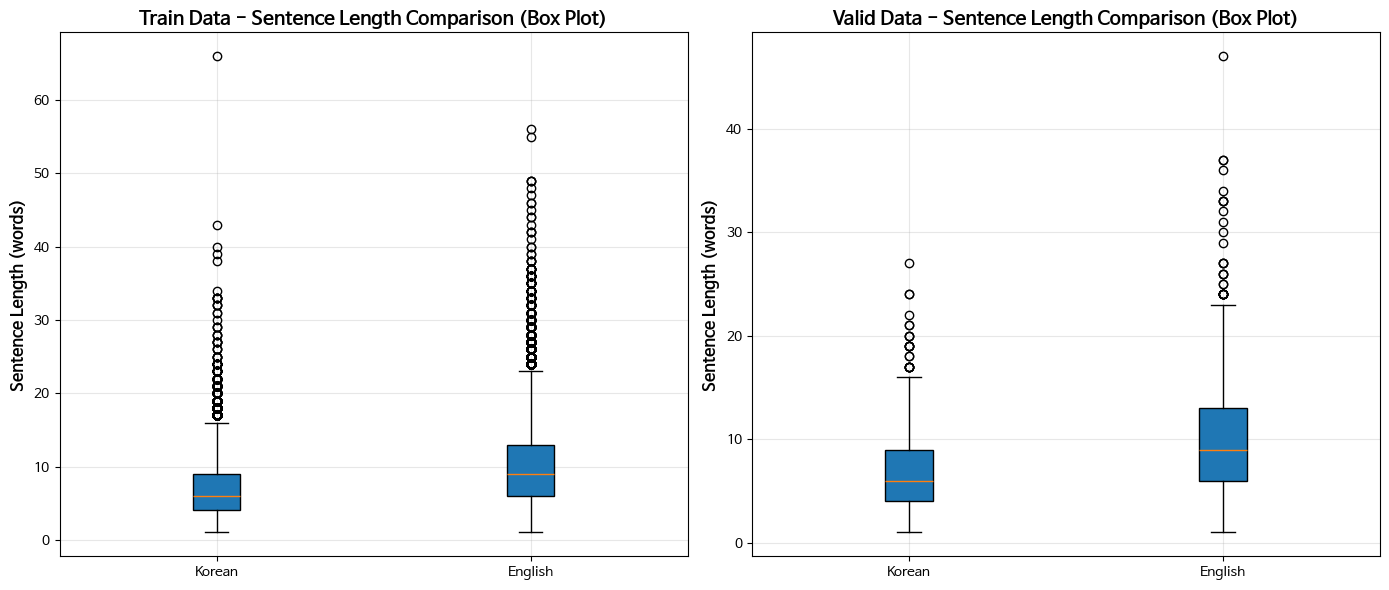

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train 데이터 비교
box_data_train = [df_train['ko_length'], df_train['mt_length']]
axes[0].boxplot(box_data_train, labels=['Korean', 'English'], patch_artist=True)
axes[0].set_ylabel('Sentence Length (words)', fontsize=12, fontweight='bold')
axes[0].set_title('Train Data - Sentence Length Comparison (Box Plot)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Valid 데이터 비교
box_data_valid = [df_valid['ko_length'], df_valid['mt_length']]
axes[1].boxplot(box_data_valid, labels=['Korean', 'English'], patch_artist=True)
axes[1].set_ylabel('Sentence Length (words)', fontsize=12, fontweight='bold')
axes[1].set_title('Valid Data - Sentence Length Comparison (Box Plot)', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./result/미션11/EDA/sentence_length_boxplot.png', dpi=300, bbox_inches='tight')
print("✅ Sentence length box plot saved as 'sentence_length_boxplot.png'")
plt.show()

#### (EDA) 특수문자 & 숫자 포함 비율

In [20]:
def count_special_chars(text):
    return len(re.findall(r'[!@#$%^&*(),.?":;_\-\']', text))

def count_digits(text):
    return len(re.findall(r'\d', text))

In [21]:
df_train['special_chars_ko'] = df_train['ko'].apply(count_special_chars)
df_train['special_chars_mt'] = df_train['mt'].apply(count_special_chars)
df_train['digits_ko'] = df_train['ko'].apply(count_digits)
df_train['digits_mt'] = df_train['mt'].apply(count_digits)

In [22]:
special_ratio_ko = (df_train['special_chars_ko'] > 0).sum() / len(df_train) * 100
special_ratio_mt = (df_train['special_chars_mt'] > 0).sum() / len(df_train) * 100
digit_ratio_ko = (df_train['digits_ko'] > 0).sum() / len(df_train) * 100
digit_ratio_mt = (df_train['digits_mt'] > 0).sum() / len(df_train) * 100

In [23]:
print(f"Train - 특수문자 포함 (한글): {special_ratio_ko:.2f}%")
print(f"Train - 특수문자 포함 (영어): {special_ratio_mt:.2f}%")
print(f"Train - 숫자 포함 (한글): {digit_ratio_ko:.2f}%")
print(f"Train - 숫자 포함 (영어): {digit_ratio_mt:.2f}%")

Train - 특수문자 포함 (한글): 98.12%
Train - 특수문자 포함 (영어): 98.69%
Train - 숫자 포함 (한글): 10.31%
Train - 숫자 포함 (영어): 8.50%


#### (EDA) 어휘 다양성 (Vocabulary Size)

In [24]:
ko_vocab = set()
mt_vocab = set()

for text in df_train['ko']:
    ko_vocab.update(text.split())

for text in df_train['mt']:
    mt_vocab.update(text.lower().split())

In [25]:
print(f"Train - 한글 unique 단어: {len(ko_vocab)}")
print(f"Train - 영어 unique 단어: {len(mt_vocab)}")

Train - 한글 unique 단어: 84864
Train - 영어 unique 단어: 32250


한글 단어의 규모가 더 큰 것이 확인되었고 약 2.6배 정도 차이가 난다.

#### (EDA) 문장 길이 분포 시각화

In [26]:
print("\n한글 문장 길이 분포:")
print(df_train['ko_length'].describe())
print("\n영어 문장 길이 분포:")
print(df_train['mt_length'].describe())


한글 문장 길이 분포:
count    50000.000000
mean         6.530100
std          3.917244
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         66.000000
Name: ko_length, dtype: float64

영어 문장 길이 분포:
count    50000.000000
mean         9.830020
std          5.808415
min          1.000000
25%          6.000000
50%          9.000000
75%         13.000000
max         56.000000
Name: mt_length, dtype: float64


✅ Sentence length distribution saved as 'sentence_length_distribution.png'


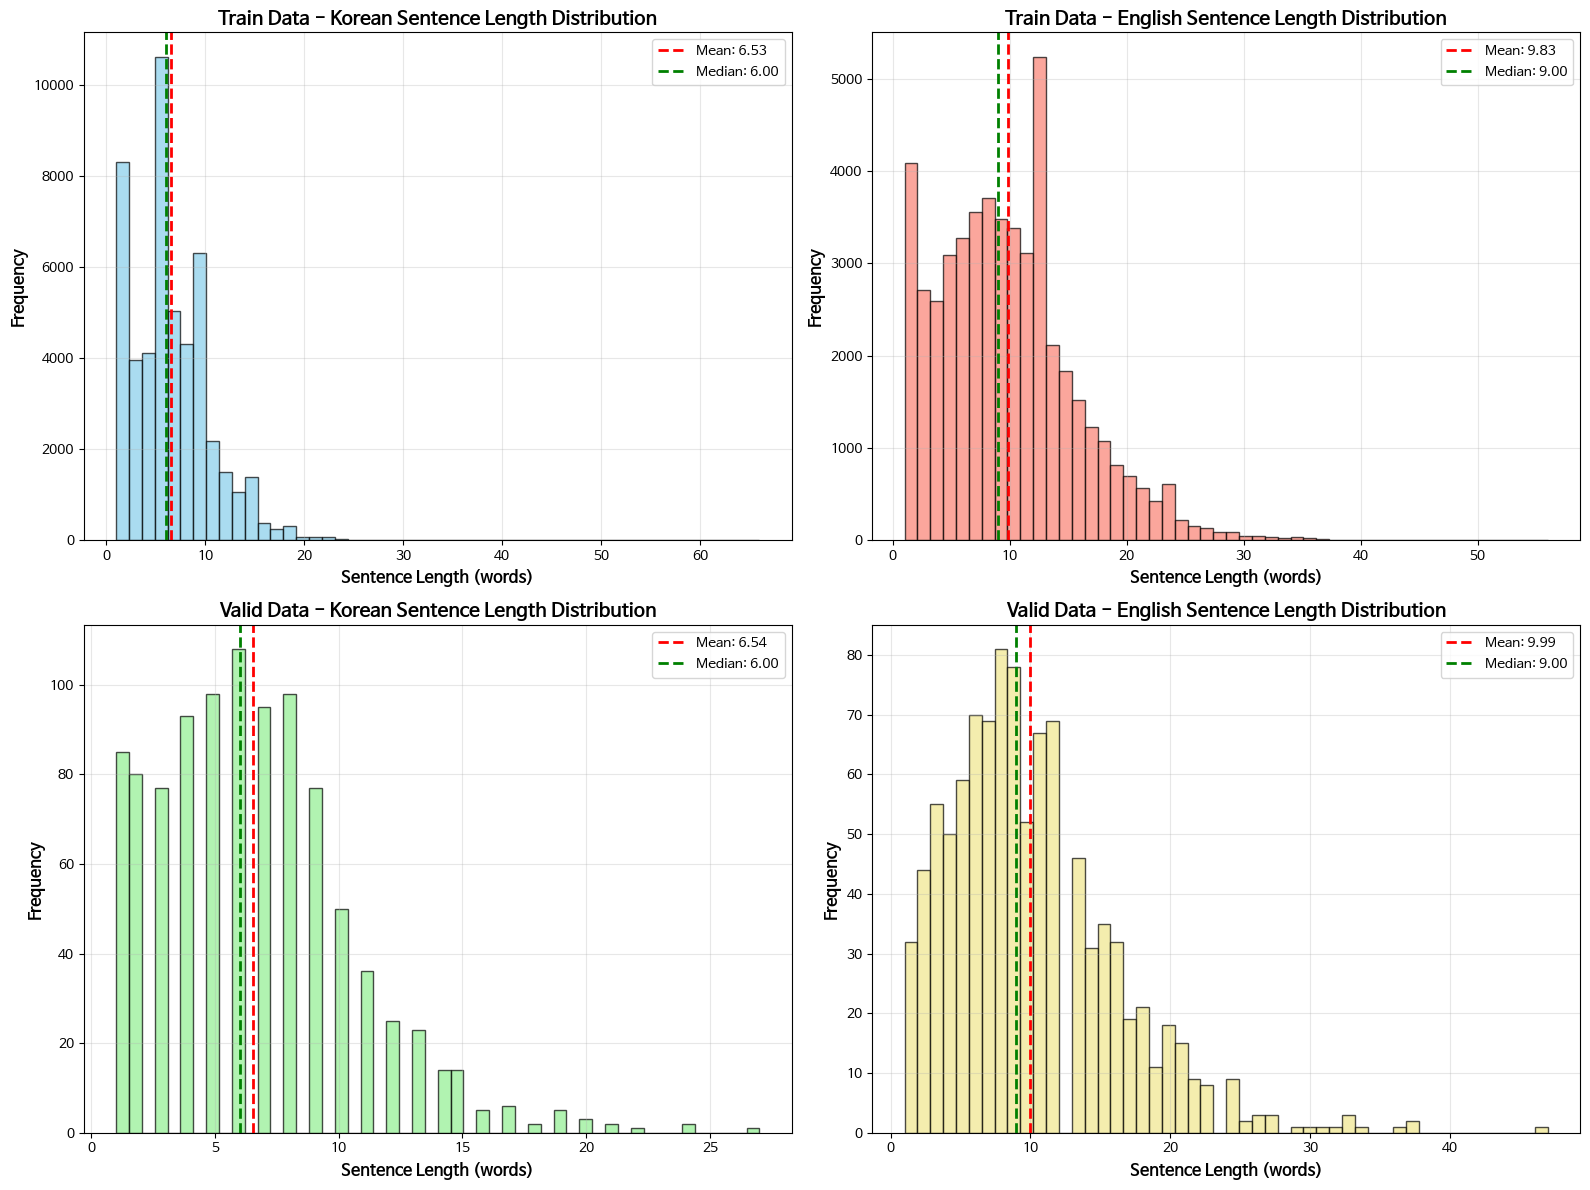

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Train 한글 문장 길이 (히스토그램)
axes[0, 0].hist(df_train['ko_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Sentence Length (words)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Train Data - Korean Sentence Length Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df_train['ko_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_train["ko_length"].mean():.2f}')
axes[0, 0].axvline(df_train['ko_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_train["ko_length"].median():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Train 영어 문장 길이 (히스토그램)
axes[0, 1].hist(df_train['mt_length'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Sentence Length (words)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Train Data - English Sentence Length Distribution', fontsize=14, fontweight='bold')
axes[0, 1].axvline(df_train['mt_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_train["mt_length"].mean():.2f}')
axes[0, 1].axvline(df_train['mt_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_train["mt_length"].median():.2f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Valid 한글 문장 길이 (히스토그램)
axes[1, 0].hist(df_valid['ko_length'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Sentence Length (words)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Valid Data - Korean Sentence Length Distribution', fontsize=14, fontweight='bold')
axes[1, 0].axvline(df_valid['ko_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_valid["ko_length"].mean():.2f}')
axes[1, 0].axvline(df_valid['ko_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_valid["ko_length"].median():.2f}')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Valid 영어 문장 길이 (히스토그램)
axes[1, 1].hist(df_valid['mt_length'], bins=50, color='khaki', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Sentence Length (words)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Valid Data - English Sentence Length Distribution', fontsize=14, fontweight='bold')
axes[1, 1].axvline(df_valid['mt_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_valid["mt_length"].mean():.2f}')
axes[1, 1].axvline(df_valid['mt_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_valid["mt_length"].median():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./result/미션11/EDA/sentence_length_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Sentence length distribution saved as 'sentence_length_distribution.png'")
plt.show()

✅ Sentence length correlation plot saved as 'sentence_length_correlation.png'


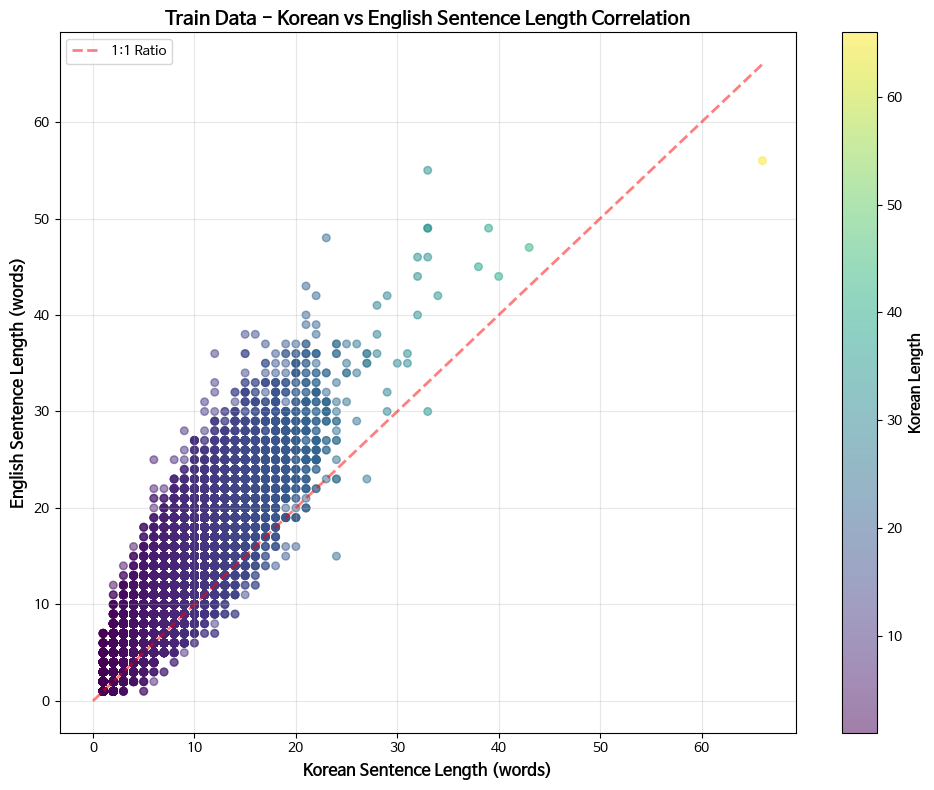

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(df_train['ko_length'], df_train['mt_length'], alpha=0.5, s=30, c=df_train['ko_length'], cmap='viridis')
ax.set_xlabel('Korean Sentence Length (words)', fontsize=12, fontweight='bold')
ax.set_ylabel('English Sentence Length (words)', fontsize=12, fontweight='bold')
ax.set_title('Train Data - Korean vs English Sentence Length Correlation', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Korean Length', fontsize=11, fontweight='bold')

# 대각선 그리기 (1:1 비율)
max_len = max(df_train['ko_length'].max(), df_train['mt_length'].max())
ax.plot([0, max_len], [0, max_len], 'r--', alpha=0.5, linewidth=2, label='1:1 Ratio')
ax.legend()

plt.tight_layout()
plt.savefig('./result/미션11/EDA/sentence_length_correlation.png', dpi=300, bbox_inches='tight')
print("✅ Sentence length correlation plot saved as 'sentence_length_correlation.png'")
plt.show()

#### (EDA) 데이터 불균형 확인

In [27]:
if 'domain' in df_train.columns:
    print("\nTrain - 도메인 분포:")
    print(df_train['domain'].value_counts())

if 'subdomain' in df_train.columns:
    print("\nTrain - 서브도메인 분포:")
    print(df_train['subdomain'].value_counts())


Train - 도메인 분포:
domain
해외영업        23281
일상생활        16777
해외고객과의채팅     9942
Name: count, dtype: int64

Train - 서브도메인 분포:
subdomain
도소매유통        19592
음식            6766
여행            5068
연구개발,과학기술     4027
정보통신          3436
구매            3322
숙박,음식점        2683
기계장비,의료정밀     1802
예약            1621
부동산           1161
금융,보험          522
Name: count, dtype: int64


In [28]:
# 문장 길이 극단값 확인
short_sentences = (df_train['ko_length'] < 2).sum()
long_sentences = (df_train['ko_length'] > 50).sum()

In [29]:
print(f"  매우 짧은 문장 (< 2단어): {short_sentences}")
print(f"  매우 긴 문장 (> 50단어): {long_sentences}")

  매우 짧은 문장 (< 2단어): 4106
  매우 긴 문장 (> 50단어): 1


✅ Domain distribution saved as 'domain_distribution.png'


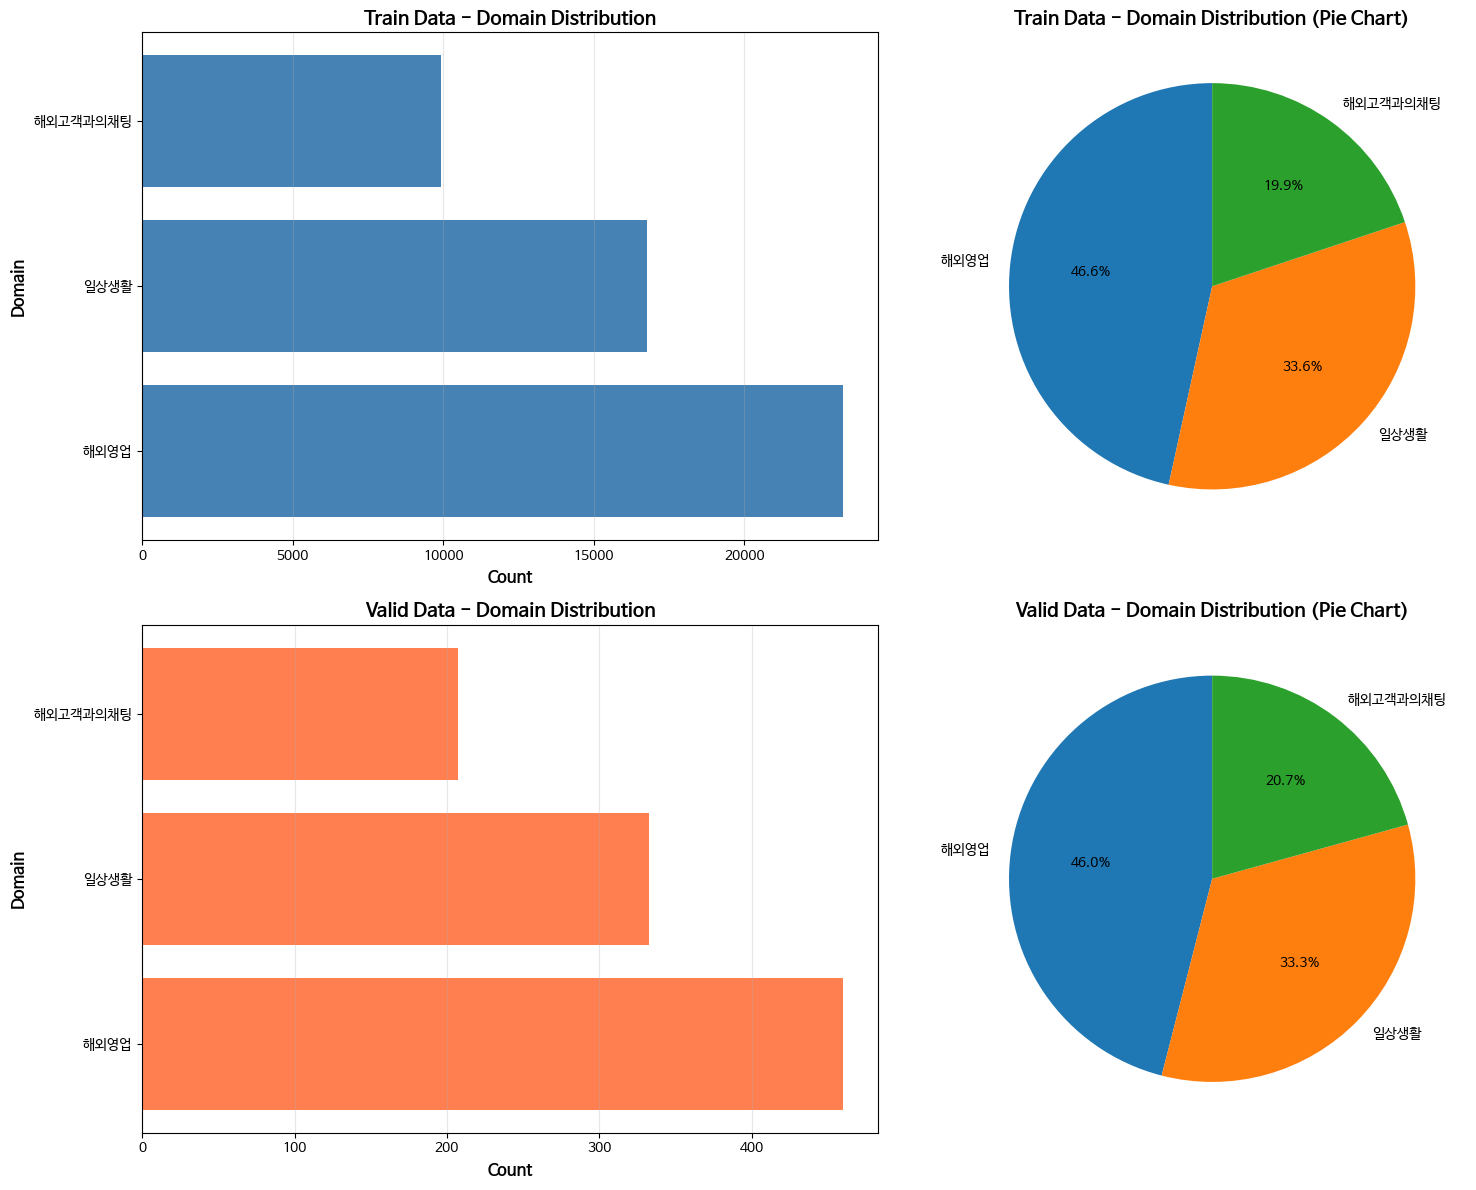

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Train 도메인 분포 (막대 그래프)
domain_dist_train = df_train['domain'].value_counts()
axes[0, 0].barh(domain_dist_train.index, domain_dist_train.values, color='steelblue')
axes[0, 0].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Domain', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Train Data - Domain Distribution', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Train 도메인 분포 (파이 차트)
axes[0, 1].pie(domain_dist_train.values, labels=domain_dist_train.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Train Data - Domain Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Valid 도메인 분포 (막대 그래프)
domain_dist_valid = df_valid['domain'].value_counts()
axes[1, 0].barh(domain_dist_valid.index, domain_dist_valid.values, color='coral')
axes[1, 0].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Domain', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Valid Data - Domain Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Valid 도메인 분포 (파이 차트)
axes[1, 1].pie(domain_dist_valid.values, labels=domain_dist_valid.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Valid Data - Domain Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./result/미션11/EDA/domain_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Domain distribution saved as 'domain_distribution.png'")
plt.show()